# Golden Baseline: ResNet50 (Messlatte)

Einfachstes sinnvolles Modell als Referenzpunkt. Jedes komplexere Modell muss beweisen, dass es diese Baseline schlägt — sonst rechtfertigt der Mehraufwand sich nicht.

Bewusst simpel gehalten: keine fortgeschrittene Augmentation, kein Mixed Precision, kein Two-Phase Training, kein mehrschichtiger Klassifikationskopf.

| Eigenschaft | Wert |
|---|---|
| Modell | ResNet50 (pretrained=True) |
| Bildgröße | 224×224 |
| Augmentation | nur HorizontalFlip |
| Verlustfunktion | CrossEntropyLoss mit Klassengewichten |
| Optimizer | Adam, lr=1e-4 |
| Epochen | 5 |
| Zielmetrik | Macro-F1 |

## 1. Imports, Konfiguration und Reproduzierbarkeit

In [1]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import f1_score, classification_report, confusion_matrix

print('Alle Bibliotheken geladen.')

<jemalloc>: Unsupported system page size


Alle Bibliotheken geladen.


In [2]:
# Reproduzierbarkeit: alle Zufallsgeneratoren auf denselben Zustand setzen.
# Ohne feste Seeds sind Vergleiche zwischen Experimenten wertlos.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False  # Pflicht bei deterministic=True

# Pfade -- identisch zur merged.ipynb.
# Die image_id-Spalte enthaelt bereits die .jpg-Endung; kein Suffix anhaengen.
DATA_DIR         = '/datasets/multi-view-pig-posture-recognition'
TRAIN2_IMAGE_DIR = os.path.join(DATA_DIR, 'train2_images')

# Modellparameter
# IMAGE_SIZE=224: Standard-Eingabe fuer ImageNet-vortrainierte Modelle.

IMAGE_SIZE  = 224
BATCH_SIZE  = 64
NUM_CLASSES = 5
NUM_WORKERS = 4
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CLASS_NAMES = [
    'Lateral_lying_left',
    'Lateral_lying_right',
    'Sitting',
    'Standing',
    'Sternal_lying'
]

print(f'Geraet: {DEVICE}')

Geraet: cuda


## 2. Daten laden

In [3]:
# Wir verwenden ausschliesslich Train Set 2, weil es mehr Kameraperspektiven
# abdeckt und damit der Testverteilung naeher kommt als Train Set 1.
train2_df = pd.read_csv(os.path.join(DATA_DIR, 'train2.csv'))

def parse_bbox(bbox_str):
    """Konvertiert Bounding-Box-String [x, y, w, h] in eine Liste von Floats."""
    return list(map(float, str(bbox_str).strip('[]').split(',')))

train2_df['bbox_parsed'] = train2_df['bbox'].apply(parse_bbox)

print(f'Train2: {len(train2_df)} Eintraege')
print(f'Spalten: {list(train2_df.columns)}')
train2_df.head(3)

Train2: 23450 Eintraege
Spalten: ['row_id', 'image_id', 'width', 'height', 'bbox', 'class_id', 'bbox_parsed']


,row_id,image_id,width,height,bbox,class_id,bbox_parsed
0,train_pen1_orb_cam1_20250108_085204_0000,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5,368.0,349.0,435.0]",0,"[1031.5, 368.0, 349.0, 435.0]"
1,train_pen1_orb_cam1_20250108_085204_0001,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5,428.0,233.0,438.0]",4,"[1278.5, 428.0, 233.0, 438.0]"
2,train_pen1_orb_cam1_20250108_085204_0002,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0,137.5,342.0,198.0]",1,"[732.0, 137.5, 342.0, 198.0]"


In [4]:
def extract_camera_info(image_id):
    """
    Extrahiert strukturierte Kamerainformationen aus dem Dateinamen.
    Tatsaechliches Format: pen1_orb_cam1_20250108_085204.jpg

    Warum frame_id? Mehrere Kameras nehmen denselben Stallbereich zum
    selben Zeitpunkt auf (Multi-View). Durch Entfernen der cam-Nummer
    erhalten synchrone Aufnahmen (z.B. cam1 und cam2 vom selben Zeitstempel)
    dieselbe frame_id -- GroupShuffleSplit haelt sie in derselben Split-Haelfte.
    """
    s = str(image_id)
    m_pen  = re.search(r'^(pen\d+)', s)
    m_type = re.search(r'_(orb|tur)_', s)
    m_num  = re.search(r'cam(\d+)', s)

    if m_pen and m_type and m_num:
        pen      = m_pen.group(1)
        cam_type = m_type.group(1)
        cam_num  = m_num.group(1)
        frame_id = re.sub(r'_cam\d+', '', s)
        return {
            'pen_id':         pen,
            'camera_type':    cam_type,
            'camera_number':  cam_num,
            'camera_view_id': f'{pen}_{cam_type}_cam{cam_num}',
            'frame_id':       frame_id
        }
    # Fallback: frame_id = image_id, damit GroupShuffleSplit eine Gruppe zuweisen kann.
    return {'pen_id': None, 'camera_type': None, 'camera_number': None,
            'camera_view_id': None, 'frame_id': str(image_id)}

info = train2_df['image_id'].apply(extract_camera_info).apply(pd.Series)
for col in info.columns:
    train2_df[col] = info[col]

no_match = train2_df['pen_id'].isna().sum()
if no_match > 0:
    print(f'Warnung: {no_match} Zeile(n) ohne Regex-Match -- frame_id = image_id gesetzt')

print(f'Eindeutige Frames in Train2: {train2_df["frame_id"].nunique()}')

Eindeutige Frames in Train2: 3084


## 3. Datensplit

**Warum GroupShuffleSplit mit frame_id?**  
Ein einzelnes Kamerabild enthält oft mehrere Schweine -- jedes ergibt eine eigene Zeile. Ein zufälliger Split koennte Schweine aus **demselben Bild** in Train und Validation aufteilen. Das Modell sähe dann beim Training fast identische Bilder, die es in der Validation vorhersagen soll: Data Leakage. `GroupShuffleSplit` mit `frame_id` als Gruppe verhindert das, indem alle Einträge eines Frames immer in dieselbe Teilmenge fallen.

In [5]:
# Identischer Split wie in merged.ipynb
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(gss.split(train2_df, groups=train2_df['frame_id']))

train_split = train2_df.iloc[train_idx].reset_index(drop=True)
val_split   = train2_df.iloc[val_idx].reset_index(drop=True)

print(f'Trainingsgroesse:    {len(train_split):>6} Eintraege')
print(f'Validierungsgroesse: {len(val_split):>6} Eintraege')
print(f'\nKlassenverteilung Training:')
print(train_split['class_id'].value_counts().sort_index())

Trainingsgroesse:     18745 Eintraege
Validierungsgroesse:   4705 Eintraege

Klassenverteilung Training:
class_id
0    2445
1    2728
2     547
3    8002
4    5023
Name: count, dtype: int64


## 4. Dataset

In [6]:
class PigCropDataset(Dataset):
    """
    Laedt Schweine-Ausschnitte anhand von Bounding Boxes.
    15% Padding und Square-Padding sind datenseitige Grundvoraussetzungen
    und bleiben in allen Experimenten erhalten.
    """

    def __init__(self, df, image_dir, transform=None, padding=0.15):
        self.df        = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self.padding   = padding

    def _load_crop(self, idx):
        row = self.df.iloc[idx]
        # image_id enthaelt bereits die .jpg-Endung -- kein Suffix anhaengen.
        img_path = os.path.join(self.image_dir, row['image_id'])
        img = Image.open(img_path).convert('RGB')

        x, y, w, h = row['bbox_parsed']

        # 15% Padding: erhalt etwas Kontext um das Tier
        x1 = max(0, int(x - w * self.padding))
        y1 = max(0, int(y - h * self.padding))
        x2 = min(img.width,  int(x + w * (1 + self.padding)))
        y2 = min(img.height, int(y + h * (1 + self.padding)))
        crop = img.crop((x1, y1, x2, y2))

        # Square-Padding statt Strecken: Haltung wird nicht verzerrt
        max_side = max(crop.width, crop.height)
        square   = Image.new('RGB', (max_side, max_side), (0, 0, 0))
        offset_x = (max_side - crop.width)  // 2
        offset_y = (max_side - crop.height) // 2
        square.paste(crop, (offset_x, offset_y))

        return square

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = self._load_crop(idx)
        if self.transform:
            img = self.transform(img)
        if 'class_id' in self.df.columns:
            return img, int(self.df.iloc[idx]['class_id'])
        return img

## 5. Augmentation

Bewusst minimale Augmentation, da Baseline.

In [7]:
# ImageNet-Normalisierungswerte: Standard fuer alle vortrainierten Modelle
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print('Augmentation-Pipeline definiert.')

Augmentation-Pipeline definiert.


In [8]:
train_dataset = PigCropDataset(train_split, TRAIN2_IMAGE_DIR, transform=train_transform)
val_dataset   = PigCropDataset(val_split,   TRAIN2_IMAGE_DIR, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,   shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE*2, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train-Batches: {len(train_loader)}')
print(f'Val-Batches:   {len(val_loader)}')

Train-Batches: 293
Val-Batches:   37


## 6. Modell

In [9]:
# pretrained=True statt weights='IMAGENET1K_V1': funktioniert in allen
# PyTorch-Versionen ab 1.5, nicht erst ab 0.13
model = models.resnet50(pretrained=True)

# Letzte Schicht: 2048 Eingabemerkmale -> 5 Klassen
model.fc = nn.Linear(2048, NUM_CLASSES)

model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Gesamtparameter: {total_params:,}')
print(f'Alle Parameter trainierbar: {all(p.requires_grad for p in model.parameters())}')

/opt/conda/envs/torch/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  warnings.warn(
/opt/conda/envs/torch/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/jovyan/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


  0%|          | 0.00/97.8M [00:00<?, ?B/s]

Gesamtparameter: 23,518,277
Alle Parameter trainierbar: True


## 7. Klassengewichte und Verlustfunktion

**Warum Klassengewichte?**  
Standing macht ~40% des Datensatzes aus, Sitting nur ~3%. Ohne Gegenmassnahmen ignoriert das Modell seltene Klassen.

In [10]:
# Inverse Haeufigkeit: seltene Klassen erhalten hoehere Gewichte
class_counts = Counter(train_split['class_id'].values)
total_samples = sum(class_counts.values())
class_weights = torch.tensor(
    [total_samples / (NUM_CLASSES * class_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float32
).to(DEVICE)

print('Klassengewichte (hoeher = seltener):')
for name, weight in zip(CLASS_NAMES, class_weights):
    print(f'  {name}: {weight:.3f}')

# Kein label_smoothing: existiert erst ab PyTorch 1.10, gehoert zur Optimierung
criterion = nn.CrossEntropyLoss(weight=class_weights)

Klassengewichte (hoeher = seltener):
  Lateral_lying_left: 1.533
  Lateral_lying_right: 1.374
  Sitting: 6.854
  Standing: 0.469
  Sternal_lying: 0.746


## 8. Optimizer

Adam mit lr=1e-4 ist ein verlaesslicher Standard-Ausgangspunkt. Kein Scheduler, kein Weight Decay -- auch das gehoert zu den Optimierungen.

In [11]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)
print('Optimizer: Adam, lr=1e-4')

Optimizer: Adam, lr=1e-4


## 9. Training

In [12]:
NUM_EPOCHS = 5
best_f1    = 0.0
history    = {'train_loss': [], 'val_loss': [], 'val_f1': []}

for epoch in range(1, NUM_EPOCHS + 1):

    # --- Trainingsphase ---
    model.train()
    train_loss_sum = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        # FP32: kein autocast, keine GradScaler
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss_sum += loss.item()

    train_loss = train_loss_sum / len(train_loader)

    # --- Validierungsphase ---
    model.eval()
    val_loss_sum = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            preds  = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            val_loss_sum += loss.item()

    val_loss = val_loss_sum / len(val_loader)
    val_f1   = f1_score(all_labels, all_preds, average='macro')

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)

    print(f'Epoche {epoch:>2}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.4f} | '
          f'Val Loss: {val_loss:.4f} | '
          f'Val Macro-F1: {val_f1:.4f}')

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), 'baseline_best.pth')
        print(f'  -> Bestes Modell gespeichert (F1: {val_f1:.4f})')

print(f'\nTraining abgeschlossen. Bester Val Macro-F1: {best_f1:.4f}')

Epoche  1/5 | Train Loss: 0.6899 | Val Loss: 0.3983 | Val Macro-F1: 0.7998
  -> Bestes Modell gespeichert (F1: 0.7998)
Epoche  2/5 | Train Loss: 0.3423 | Val Loss: 0.3522 | Val Macro-F1: 0.8428
  -> Bestes Modell gespeichert (F1: 0.8428)
Epoche  3/5 | Train Loss: 0.2115 | Val Loss: 0.3356 | Val Macro-F1: 0.8174
Epoche  4/5 | Train Loss: 0.1748 | Val Loss: 0.3456 | Val Macro-F1: 0.8371
Epoche  5/5 | Train Loss: 0.1137 | Val Loss: 0.4145 | Val Macro-F1: 0.8667
  -> Bestes Modell gespeichert (F1: 0.8667)

Training abgeschlossen. Bester Val Macro-F1: 0.8667


## 10. Abschliessende Auswertung

Das beste gespeicherte Modell wird geladen und auf dem Validation Set ausgewertet.

In [13]:
# Bestes Modell laden fuer die abschliessende Auswertung
model.load_state_dict(torch.load('baseline_best.pth', map_location=DEVICE))
model.eval()
print('Bestes Modell geladen.')

Bestes Modell geladen.


In [14]:
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        preds  = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print('=== Classification Report ===')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

=== Classification Report ===
                     precision    recall  f1-score   support

 Lateral_lying_left       0.92      0.90      0.91       638
Lateral_lying_right       0.91      0.87      0.89       707
            Sitting       0.62      0.76      0.68       148
           Standing       0.99      0.94      0.96      1926
      Sternal_lying       0.85      0.93      0.89      1286

           accuracy                           0.91      4705
          macro avg       0.86      0.88      0.87      4705
       weighted avg       0.92      0.91      0.92      4705



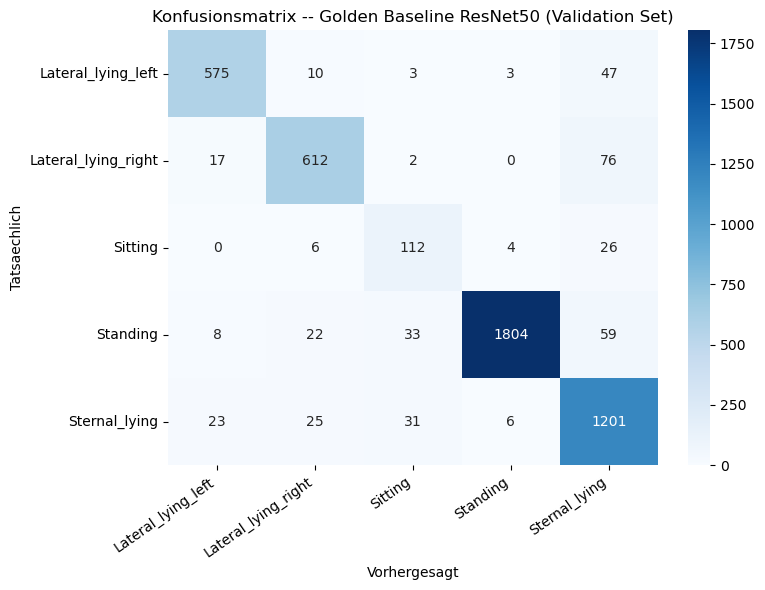

In [15]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Konfusionsmatrix -- Golden Baseline ResNet50 (Validation Set)')
plt.ylabel('Tatsaechlich')
plt.xlabel('Vorhergesagt')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('baseline_konfusionsmatrix.png', dpi=100, bbox_inches='tight')
plt.show()

In [17]:
final_f1 = f1_score(all_labels, all_preds, average='macro')

print('=' * 60)
print(f'Golden Baseline Macro-F1: {final_f1:.4f}')
print('=' * 60)

Golden Baseline Macro-F1: 0.8667


**Einordnung des hohen F1-Werts:**
Der Wert wirkt überraschend hoch für eine simple Baseline. Wichtige Einschränkung: Der GroupShuffleSplit verhindert nur Frame-Level-Leakage (dasselbe Bild in Train und Val), nicht aber Kamera-Level-Leakage — Training und Validation teilen dieselben Kameraperspektiven, Stallbereiche und Lichtverhältnisse. Das Modell kann den hohen F1 daher auch durch kameraspezifische Merkmale wie Hintergrund oder Belichtung erreicht haben, statt durch echtes Verständnis der Haltungsmerkmale. Wie gut die Baseline auf unbekannte Kameras generalisiert, lässt sich aus diesem internen Wert nicht ableiten.